# Detecting Clickbait in Online Headlines with Neural Networks

**BA865 Neural Networks in Business: From Foundations to Generative AI**  
**Project Topic:** Detecting Clickbait in Online Headlines  

This notebook develops the data pipeline and exploratory analysis for a neural network model that predicts whether an online headline or social media post is clickbait. The task is framed as a binary text classification problem: given the text of a post, the model predicts whether the post is likely to be clickbait or not clickbait.

## 1. Project Overview

Online news publishers and social media platforms often compete for user attention. One common strategy is the use of clickbait: headlines or post text designed to attract clicks through exaggeration, ambiguity, emotional language, or misleading framing. Although clickbait may increase short-term engagement, it can reduce user trust, weaken content quality, and damage long-term platform credibility.

From a business perspective, a clickbait detection model could help digital platforms improve ranking systems, flag low-quality content, support editorial review, and protect users from misleading information. In this project, we use neural network methods to classify online post text as either clickbait or no-clickbait.

The goal of this notebook section is to prepare the dataset for modeling and understand its structure before building neural network architectures.

## 2. Dataset Description

We use the **Webis Clickbait Corpus 2017**, which contains social media posts from major U.S. news publishers. Each observation includes an online post and human judgments about whether the post is clickbait.

For this project, we primarily use the following folders:

- `train1/`
- `train2/`
- `test/`

Each folder contains two JSONL files:

- `instances.jsonl`: input feature data, including the post text and related article metadata.
- `truth.jsonl`: label data, including human clickbait judgments.

The key fields used in this notebook are:

- `id`: unique identifier used to match records across the two files.
- `postText`: the text of the online post, stored as a list of strings.
- `truthJudgments`: five human annotator scores, where higher values indicate stronger clickbait judgments.
- `truthClass`: the official binary class label, either `clickbait` or `no-clickbait`.

To make the label construction transparent, we derive the binary target variable from `truthJudgments`. Specifically, we classify a post as clickbait if the median of the five human judgments is at least `0.5`. This matches the official `truthClass` labels in the provided data.

## 3. Setup

The following cells import the libraries used for data loading, cleaning, and exploratory data analysis. The modeling section will be added later.

In [ ]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

## 4. Data Loading

This notebook is designed to run in **Google Colab** for final submission. In Colab, the dataset should be stored in Google Drive at:

```text
/content/drive/MyDrive/BA865
```

The folder should contain:

- `/content/drive/MyDrive/BA865/train1/instances.jsonl`
- `/content/drive/MyDrive/BA865/train1/truth.jsonl`
- `/content/drive/MyDrive/BA865/train2/instances.jsonl`
- `/content/drive/MyDrive/BA865/train2/truth.jsonl`
- `/content/drive/MyDrive/BA865/test/instances.jsonl`
- `/content/drive/MyDrive/BA865/test/truth.jsonl`

For convenience, the code also supports local execution. If the notebook is not running in Colab, it reads the data from the current working directory.

The function below reads a split folder, matches `instances.jsonl` and `truth.jsonl` by `id`, extracts the post text, and constructs a binary target label from the median of `truthJudgments`.

In [ ]:

import sys
import os
import subprocess
from pathlib import Path

SPLITS = ["train1", "train2", "test"]

# Reproducible dataset setup
DRIVE_FILE_IDS = {
    "train1": {
        "truth.jsonl": "1QWf7EKZLJeX9JIaIrXNeYZT-hOzTugiL",
        "instances.jsonl": "1v-VkHC3o0-wdYzbGN3wvVdtvjcODXPNn",
    },
    "train2": {
        "instances.jsonl": "1yTRUJ4VJwlodEgf_p7exBAxlcev9wCTV",
        "truth.jsonl": "1hKq4TqzN_EYKtKxHCp3L3JFMRhrutJbo",
    },
    "test": {
        "instances.jsonl": "1TbqvlOqXPhs_D5v_uqGLGVbgxg7l0fD3",
        "truth.jsonl": "1Id9UGTcX3DTB9ATwY0eGjmi7qCXc4b6q",
    },
}

DATA_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/BA865"),
    Path("/content/BA865_clickbait_data"),
    Path("/content/BA865"),
    Path("."),
]

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def dataset_is_complete(base_dir, splits=SPLITS):
    """Return True if all required split folders and JSONL files exist."""
    base_dir = Path(base_dir)
    required_files = []
    for split in splits:
        required_files.extend([
            base_dir / split / "instances.jsonl",
            base_dir / split / "truth.jsonl",
        ])
    return all(path.exists() and path.stat().st_size > 0 for path in required_files)


def download_from_google_drive(file_id, destination):
    """Download one shared Google Drive file to a local Colab path."""
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    # Install gdown only if needed.
    try:
        import gdown
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
        import gdown

    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, str(destination), quiet=False, fuzzy=True)

    if not destination.exists() or destination.stat().st_size == 0:
        raise FileNotFoundError(f"Download failed or produced an empty file: {destination}")

    return destination


def download_dataset_from_drive(download_dir=Path("/content/BA865_clickbait_data")):
    """Download all six JSONL files from Google Drive into a Colab-local folder."""
    download_dir = Path(download_dir)
    print(f"Downloading dataset files to: {download_dir}")

    for split, files in DRIVE_FILE_IDS.items():
        for filename, file_id in files.items():
            output_path = download_dir / split / filename
            if output_path.exists() and output_path.stat().st_size > 0:
                print(f"Already exists, skipping: {output_path}")
                continue
            print(f"Downloading {split}/{filename} ...")
            download_from_google_drive(file_id, output_path)

    return download_dir


def find_dataset_dir():
    """Find a complete existing dataset folder from common locations."""
    for candidate in DATA_DIR_CANDIDATES:
        if dataset_is_complete(candidate):
            return candidate
    return None


if IN_COLAB:
    drive.mount("/content/drive")

DATA_DIR = find_dataset_dir()

if DATA_DIR is None:
    DATA_DIR = download_dataset_from_drive()

# Final validation before continuing.
if not dataset_is_complete(DATA_DIR):
    expected_structure = "\n".join([
        "Dataset setup failed. Expected these files:",
        "DATA_DIR/train1/instances.jsonl",
        "DATA_DIR/train1/truth.jsonl",
        "DATA_DIR/train2/instances.jsonl",
        "DATA_DIR/train2/truth.jsonl",
        "DATA_DIR/test/instances.jsonl",
        "DATA_DIR/test/truth.jsonl",
        "",
        "Fixes:",
        "1. Make sure the Google Drive file links are shared as 'Anyone with the link can view'.",
        "2. Or manually place the BA865 folder at /content/drive/MyDrive/BA865.",
        "3. Or upload train1, train2, and test folders beside this notebook.",
    ])
    raise FileNotFoundError(expected_structure)

DATA_DIR = Path(DATA_DIR)
print("Running in Colab:", IN_COLAB)
print("Using dataset directory:", DATA_DIR.resolve())
print("All expected dataset files were found.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloading...
From: https://drive.google.com/uc?id=1QWf7EKZLJeX9JIaIrXNeYZT-hOzTugiL
To: /content/BA865_clickbait_data/train1/truth.jsonl
100%|██████████| 419k/419k [00:00<00:00, 6.07MB/s]


Downloading...
From: https://drive.google.com/uc?id=1v-VkHC3o0-wdYzbGN3wvVdtvjcODXPNn
To: /content/BA865_clickbait_data/train1/instances.jsonl
100%|██████████| 12.5M/12.5M [00:00<00:00, 64.9MB/s]


Downloading...
From: https://drive.google.com/uc?id=1yTRUJ4VJwlodEgf_p7exBAxlcev9wCTV
To: /content/BA865_clickbait_data/train2/instances.jsonl
100%|██████████| 95.6M/95.6M [00:01<00:00, 53.4MB/s]


Downloading...
From: https://drive.google.com/uc?id=1hKq4TqzN_EYKtKxHCp3L3JFMRhrutJbo
To: /content/BA865_clickbait_data/train2/truth.jsonl
100%|██████████| 3.75M/3.75M [00:00<00:00, 26.4MB/s]


Downloading...
From: https://drive.google.com/uc?id=1TbqvlOqXPhs_D5v_uqGLGVbgxg7l0fD3
To: /content/BA865_clickbait_data/test/instances.jsonl
100%|██████████| 90.0M/90.0M [00:01<00:00, 46.7MB/s]


Downloading...
From: https://drive.google.com/uc?id=1Id9UGTcX3DTB9ATwY0eGjmi7qCXc4b6q
To: /content/BA865_clickbait_data/test/truth.jsonl
100%|██████████| 3.57M/3.57M [00:00<00:00, 25.5MB/s]

Running in Colab: True
Using dataset directory: /content/BA865_clickbait_data
All expected dataset files were found.


In [ ]:
def read_jsonl(path):
    """Read a JSONL file and return a list of dictionaries."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def clean_post_text(post_text):
    """Convert the postText list into a single clean text string."""
    if post_text is None:
        return ""
    if isinstance(post_text, list):
        text = " ".join(str(part) for part in post_text)
    else:
        text = str(post_text)

    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def label_from_judgments(judgments):
    """Convert five human clickbait judgments into a binary label using the median."""
    return int(np.median(judgments) >= 0.5)


def load_split(split_name, data_dir=DATA_DIR):
    """Load one dataset split by matching instances and truth records on id."""
    split_path = data_dir / split_name

    instances = {row["id"]: row for row in read_jsonl(split_path / "instances.jsonl")}
    truths = {row["id"]: row for row in read_jsonl(split_path / "truth.jsonl")}

    instance_ids = set(instances)
    truth_ids = set(truths)
    matched_ids = sorted(instance_ids & truth_ids)

    rows = []
    for record_id in matched_ids:
        instance = instances[record_id]
        truth = truths[record_id]
        text = clean_post_text(instance.get("postText", []))
        judgments = truth["truthJudgments"]

        rows.append({
            "id": record_id,
            "split": split_name,
            "text": text,
            "label": label_from_judgments(judgments),
            "truth_judgments": judgments,
            "truth_mean": float(np.mean(judgments)),
            "truth_median": float(np.median(judgments)),
            "truth_mode": truth.get("truthMode"),
            "truth_class": truth.get("truthClass"),
            "official_label": int(truth.get("truthClass") == "clickbait"),
            "post_timestamp": instance.get("postTimestamp"),
            "has_media": int(len(instance.get("postMedia", [])) > 0),
            "target_title": instance.get("targetTitle", ""),
        })

    df = pd.DataFrame(rows)
    df["char_count"] = df["text"].str.len()
    df["word_count"] = df["text"].str.split().str.len().fillna(0).astype(int)
    df["is_empty_text"] = df["text"].eq("")

    report = {
        "split": split_name,
        "instances": len(instances),
        "truth": len(truths),
        "matched": len(matched_ids),
        "missing_truth": len(instance_ids - truth_ids),
        "missing_instances": len(truth_ids - instance_ids),
        "duplicate_ids_in_output": int(df["id"].duplicated().sum()),
    }

    return df, report

In [ ]:
split_frames = []
match_reports = []

for split in SPLITS:
    split_df, report = load_split(split)
    split_frames.append(split_df)
    match_reports.append(report)

all_df = pd.concat(split_frames, ignore_index=True)
train_df = all_df[all_df["split"].isin(["train1", "train2"])].reset_index(drop=True)
test_df = all_df[all_df["split"].eq("test")].reset_index(drop=True)

match_report_df = pd.DataFrame(match_reports)
match_report_df

,split,instances,truth,matched,missing_truth,missing_instances,duplicate_ids_in_output
0,train1,2459,2459,2459,0,0,0
1,train2,19538,19538,19538,0,0,0
2,test,18979,18979,18979,0,0,0


The match report confirms whether every input record has a corresponding label record. A clean match is important because the model input comes from `instances.jsonl`, while the supervised label comes from `truth.jsonl`.

In [ ]:
print(f"Combined training rows: {len(train_df):,}")
print(f"Final test rows: {len(test_df):,}")
print(f"All rows loaded: {len(all_df):,}")

all_df.head()

Combined training rows: 21,997
Final test rows: 18,979
All rows loaded: 40,976


,id,split,text,label,truth_judgments,truth_mean,truth_median,truth_mode,truth_class,official_label,post_timestamp,has_media,target_title,char_count,word_count,is_empty_text
0,607668877594497024,train1,RT @WSJLive: This year's Tony nominees desribe some of their craziest momets on stage: #TonyAwards,1,"[0.0, 0.6666667, 1.0, 1.0, 0.6666667]",0.666667,0.666667,1.000000,clickbait,1,Sun Jun 07 22:02:05 +0000 2015,0,Tony Nominees' Craziest Moments on Stage,98,15,False
1,607671137062010881,train1,Orphaned fruit bat pups nursed back to health in animal sanctuary,0,"[0.33333334, 0.0, 0.0, 0.0, 0.0]",0.066667,0.000000,0.000000,no-clickbait,0,Sun Jun 07 22:11:03 +0000 2015,1,Going into bat to save a species: Dedication and a nice warm blanket helping to save endangered fruit bats,65,11,False
2,607672568057700352,train1,"Ohio State’s Tyvis Powell learned that champion or not, you still do chores #MomWins",0,"[0.0, 0.0, 0.6666667, 0.33333334, 0.0]",0.200000,0.000000,0.000000,no-clickbait,0,Sun Jun 07 22:16:44 +0000 2015,1,"Ohio State's Tyvis Powell Thinks He's Above Cutting Grass, Mom Says No",84,14,False
3,607674674168926209,train1,China’s fishermen explain why they think the sea is theirs,1,"[1.0, 0.6666667, 0.33333334, 0.6666667, 0.33333334]",0.600000,0.666667,0.666667,clickbait,1,Sun Jun 07 22:25:07 +0000 2015,0,China’s fishermen explain why they think the sea is theirs,58,10,False
4,607675444834398208,train1,"RT @BBCSport: ""I'm living my dream"" - Watch what Lewis Hamilton had to say after #CanadianGP win: #bbcf1 http://t.co",0,"[0.33333334, 0.6666667, 0.0, 0.0, 0.6666667]",0.333333,0.333333,0.000000,no-clickbait,0,Sun Jun 07 22:28:10 +0000 2015,1,BBC Sport - Lewis Hamilton 'living his dream' after Canada win Winner Hamilton 'living his dream',116,19,False


## 5. Label Construction Check

Although the dataset provides an official `truthClass`, we construct the binary label from `truthJudgments` to keep the label-generation process explicit. The next cell checks whether our median-based label matches the official class label.

In [ ]:
label_check = (
    all_df.assign(label_matches_official=all_df["label"].eq(all_df["official_label"]))
    .groupby("split")
    .agg(
        rows=("id", "count"),
        matches=("label_matches_official", "sum"),
        mismatches=("label_matches_official", lambda x: (~x).sum()),
        match_rate=("label_matches_official", "mean"),
    )
    .reset_index()
)

label_check["match_rate"] = label_check["match_rate"].map(lambda x: f"{x:.2%}")
label_check

,split,rows,matches,mismatches,match_rate
0,test,18979,18979,0,100.00%
1,train1,2459,2459,0,100.00%
2,train2,19538,19538,0,100.00%


Since the median-based label matches the official `truthClass`, we use the derived `label` variable for modeling:

- `0`: no-clickbait
- `1`: clickbait

## 6. Exploratory Data Analysis

This section summarizes the size of each split, class balance, text length, human judgment patterns, and examples from each class. These checks help determine whether the classification task is balanced, whether empty text records need to be handled, and what model evaluation metrics are appropriate.

In [ ]:
def label_name(label):
    return "clickbait" if label == 1 else "no-clickbait"

all_df["label_name"] = all_df["label"].map(label_name)
train_df = all_df[all_df["split"].isin(["train1", "train2"])].reset_index(drop=True)
test_df = all_df[all_df["split"].eq("test")].reset_index(drop=True)

split_summary = (
    all_df.groupby("split")
    .agg(
        rows=("id", "count"),
        clickbait=("label", "sum"),
        no_clickbait=("label", lambda x: (x == 0).sum()),
        clickbait_rate=("label", "mean"),
        empty_text_rows=("is_empty_text", "sum"),
        avg_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        max_words=("word_count", "max"),
        media_rate=("has_media", "mean"),
    )
    .reset_index()
)

split_summary["clickbait_rate"] = split_summary["clickbait_rate"].map(lambda x: f"{x:.2%}")
split_summary["media_rate"] = split_summary["media_rate"].map(lambda x: f"{x:.2%}")
split_summary["avg_words"] = split_summary["avg_words"].round(2)
split_summary

,split,rows,clickbait,no_clickbait,clickbait_rate,empty_text_rows,avg_words,median_words,max_words,media_rate
0,test,18979,4515,14464,23.79%,66,11.50,11.0,26,53.95%
1,train1,2459,762,1697,30.99%,0,12.75,12.0,27,66.00%
2,train2,19538,4761,14777,24.37%,54,11.60,12.0,25,52.75%


### 6.1 Class Balance

The following table and plot show the distribution of clickbait and no-clickbait records in each split. Because this is a binary classification task, class balance is important for model evaluation. If one class is much more common than the other, accuracy alone can be misleading.

In [ ]:
class_counts = (
    all_df.groupby(["split", "label_name"])
    .size()
    .reset_index(name="count")
)
class_counts["percent_within_split"] = class_counts.groupby("split")["count"].transform(lambda x: x / x.sum())
class_counts["percent_within_split"] = (class_counts["percent_within_split"] * 100).round(2)
class_counts

,split,label_name,count,percent_within_split
0,test,clickbait,4515,23.79
1,test,no-clickbait,14464,76.21
2,train1,clickbait,762,30.99
3,train1,no-clickbait,1697,69.01
4,train2,clickbait,4761,24.37
5,train2,no-clickbait,14777,75.63


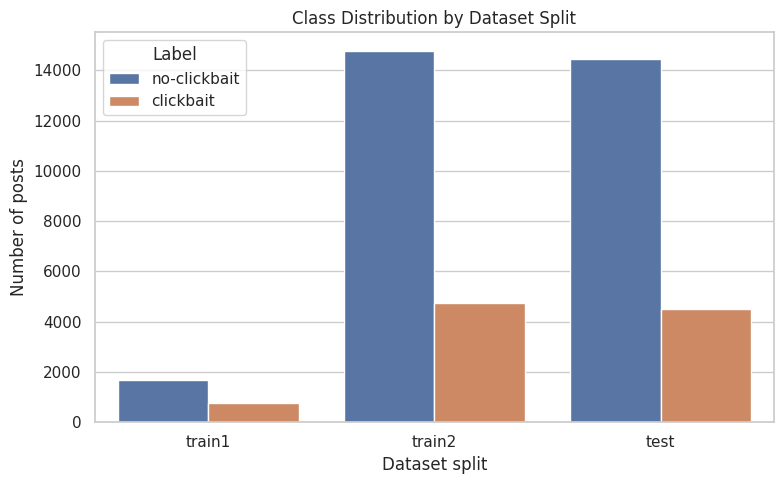

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=all_df, x="split", hue="label_name", order=SPLITS, hue_order=["no-clickbait", "clickbait"])
plt.title("Class Distribution by Dataset Split")
plt.xlabel("Dataset split")
plt.ylabel("Number of posts")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

The dataset is moderately imbalanced, with no-clickbait posts appearing more frequently than clickbait posts. For this reason, later model evaluation should include precision, recall, F1 score, and a confusion matrix in addition to accuracy.

### 6.2 Text Length

Since the model input is the post text, we examine the number of words and characters in each post. Very short or empty posts may be harder to classify from text alone.

In [ ]:
length_summary = (
    all_df.groupby(["split", "label_name"])
    .agg(
        rows=("id", "count"),
        avg_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        min_words=("word_count", "min"),
        max_words=("word_count", "max"),
        avg_chars=("char_count", "mean"),
        median_chars=("char_count", "median"),
    )
    .reset_index()
)

for col in ["avg_words", "avg_chars"]:
    length_summary[col] = length_summary[col].round(2)

length_summary

,split,label_name,rows,avg_words,median_words,min_words,max_words,avg_chars,median_chars
0,test,clickbait,4515,9.97,10.0,0,24,57.45,59.0
1,test,no-clickbait,14464,11.98,12.0,0,26,74.18,74.0
2,train1,clickbait,762,11.96,12.0,3,26,71.80,70.0
3,train1,no-clickbait,1697,13.11,13.0,3,27,81.72,81.0
4,train2,clickbait,4761,10.11,10.0,0,25,58.63,60.0
5,train2,no-clickbait,14777,12.08,12.0,0,25,74.53,74.0


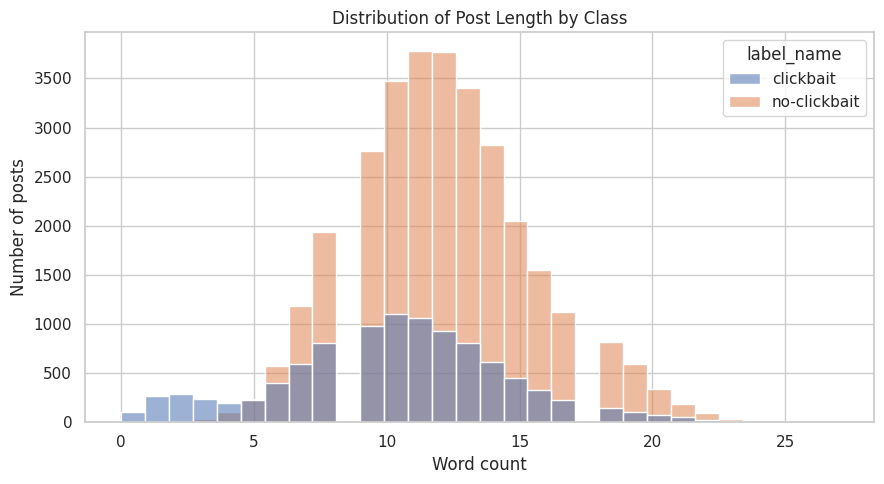

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(data=all_df, x="word_count", hue="label_name", bins=30, multiple="layer", alpha=0.55)
plt.title("Distribution of Post Length by Class")
plt.xlabel("Word count")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

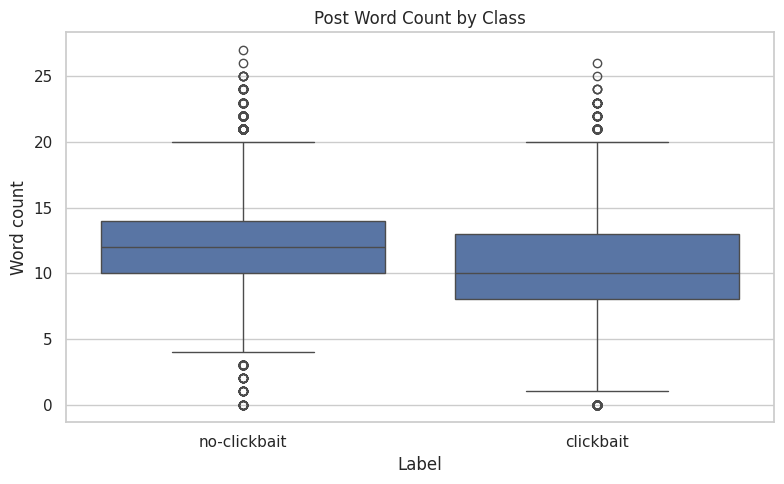

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=all_df, x="label_name", y="word_count", order=["no-clickbait", "clickbait"])
plt.title("Post Word Count by Class")
plt.xlabel("Label")
plt.ylabel("Word count")
plt.tight_layout()
plt.show()

### 6.3 Empty Text Records

A small number of records may have empty `postText`. These rows do not provide useful text input for a headline-only classifier. We identify them here so that the modeling section can decide whether to remove them or replace missing text with another available field such as `targetTitle`.

In [ ]:
empty_text_summary = (
    all_df[all_df["is_empty_text"]]
    .groupby(["split", "label_name"])
    .size()
    .reset_index(name="empty_rows")
)

empty_text_summary

,split,label_name,empty_rows
0,test,clickbait,57
1,test,no-clickbait,9
2,train2,clickbait,45
3,train2,no-clickbait,9


In [ ]:
all_df.loc[all_df["is_empty_text"], ["id", "split", "label_name", "text", "target_title"]].head(10)

,id,split,label_name,text,target_title
13121,834136493299998721,train2,clickbait,,MILO Resigns from Breitbart News
17439,845818587340169217,train2,clickbait,,Ever Wondered What's The Exact Time You Need To Sleep To Wake Up Refreshed In The Morning? Here's The Answer
18198,847940029045407744,train2,clickbait,,Rosie O’Donnell Urges Melania Trump: ‘Divorce’ Donald and ‘Flee’
18224,848018381601214465,train2,clickbait,,Italy: Muslim Mother Shaves Head of Daughter Who Refused to Wear Veil
18260,848141511309107201,train2,clickbait,,Chickens Come Home to Roost: Massive Layoffs Predicted for ESPN Broadcasters
18295,848234479344906240,train2,no-clickbait,,New York mayor vows to close Rikers Island jail complex
18334,848312710630694912,train2,clickbait,,Maher: It Looks Like Russia ‘Installed’ ‘Trump and His Crime Family’ ‘To Loot and Destroy America
18394,848522964102508544,train2,clickbait,,White House Official: Trump Seeking to ‘Reboot’ Egypt Relationship with al-Sisi Visit
18397,848529141779636225,train2,clickbait,,"Maddow Raises Possibility Trump, Campaign Innocent and ‘Scandal’ Isn’t ‘Existential Presidency-Ending Conflagration’"
18405,848535987672285184,train2,clickbait,,Two Female Texas Teachers Accused of Middle School Sex


### 6.4 Human Judgment Distribution

The labels are based on five human judgments per post. The distribution of `truth_mean` and `truth_median` shows how strongly annotators agreed that a post was clickbait.

In [ ]:
judgment_summary = (
    all_df.groupby("label_name")
    .agg(
        rows=("id", "count"),
        avg_truth_mean=("truth_mean", "mean"),
        median_truth_mean=("truth_mean", "median"),
        avg_truth_median=("truth_median", "mean"),
        median_truth_median=("truth_median", "median"),
    )
    .reset_index()
)

for col in ["avg_truth_mean", "median_truth_mean", "avg_truth_median", "median_truth_median"]:
    judgment_summary[col] = judgment_summary[col].round(3)

judgment_summary

,label_name,rows,avg_truth_mean,median_truth_mean,avg_truth_median,median_truth_median
0,clickbait,10038,0.691,0.667,0.794,0.667
1,no-clickbait,30938,0.190,0.200,0.105,0.000


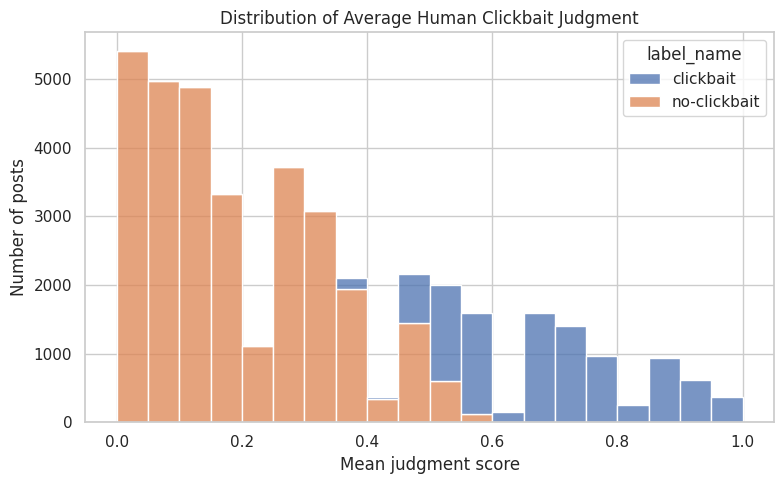

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=all_df, x="truth_mean", hue="label_name", bins=20, multiple="stack")
plt.title("Distribution of Average Human Clickbait Judgment")
plt.xlabel("Mean judgment score")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

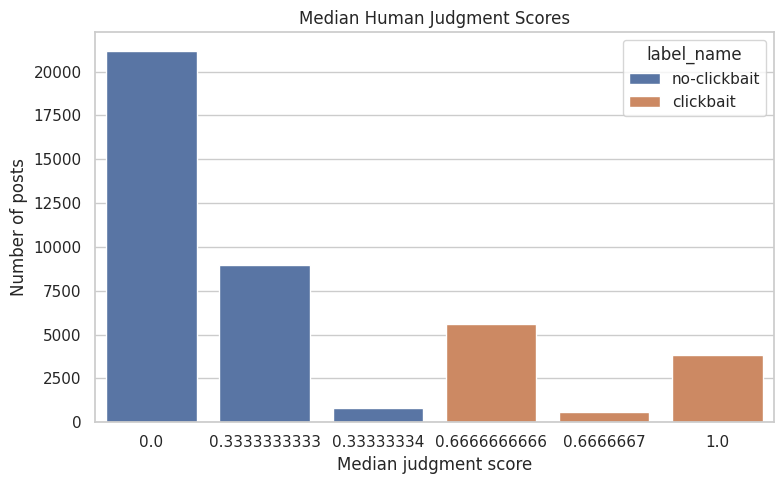

In [ ]:
median_counts = (
    all_df.groupby(["truth_median", "label_name"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))
sns.barplot(data=median_counts, x="truth_median", y="count", hue="label_name")
plt.title("Median Human Judgment Scores")
plt.xlabel("Median judgment score")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

### 6.5 Example Posts

The examples below provide a qualitative sense of the language patterns in each class. This is useful for interpreting model errors later.

In [ ]:
def show_examples(df, label, n=8):
    examples = (
        df[(df["label"] == label) & (~df["is_empty_text"])]
        .sample(n=min(n, ((df["label"] == label) & (~df["is_empty_text"])).sum()), random_state=RANDOM_STATE)
        [["split", "label_name", "truth_mean", "truth_median", "text"]]
        .reset_index(drop=True)
    )
    return examples

show_examples(all_df, label=1, n=8)

,split,label_name,truth_mean,truth_median,text
0,test,clickbait,0.600000,0.666667,The 3 plays in sports everybody will be talking about today
1,test,clickbait,0.733333,1.000000,How to beat UK energy price rises
2,train2,clickbait,0.533333,0.666667,Prince George steals the show as Royal Family leaves Christmas Day service
3,train2,clickbait,0.666667,0.666667,Trump: 'I'm only worried he's gonna give me a kiss'
4,train2,clickbait,0.600000,0.666667,Why Theaster Gates took an ax to his own painting at the NGA
5,train2,clickbait,0.733333,0.666667,News anchor learns about her husband's death during a live broadcast.
6,train2,clickbait,0.600000,0.666667,The first pictures from NOAA's newest weather satellite are incredible
7,train2,clickbait,0.666667,0.666667,These men brutally killed a #Kangaroo


In [ ]:
show_examples(all_df, label=0, n=8)

,split,label_name,truth_mean,truth_median,text
0,train2,no-clickbait,0.200000,0.0,#CSIRO backs #emissions trading scheme over RETs to lower power prices
1,test,no-clickbait,0.000000,0.0,"Rihanna, Azealia Banks clash over immigration ban, post each other’s phone numbers"
2,test,no-clickbait,0.200000,0.0,Tunisian 'sought over Berlin attack'
3,test,no-clickbait,0.066667,0.0,"Michael Flynn is gone, but a proposed peace plan for Ukraine and Russia remains, along with those pushing it"
4,train2,no-clickbait,0.000000,0.0,"Chuck Berry has died at 90, and the world's paying tribute:"
5,test,no-clickbait,0.066667,0.0,"ON @GMA: With healthcare push, Pres. Trump preps for war with his own party:"
6,train2,no-clickbait,0.133333,0.0,European stocks climb as banks advance
7,test,no-clickbait,0.000000,0.0,Mike Krzyzewski will be back on the sideline for Duke after missing the past 7 games recovering from back surgery.


### 6.6 Frequent Terms by Class

As a final EDA step, we compare common terms in clickbait and no-clickbait posts. This does not replace neural network modeling, but it helps identify visible lexical patterns that may influence model predictions.

In [ ]:
def top_terms_by_class(df, label, n_terms=20):
    texts = df[(df["label"] == label) & (~df["is_empty_text"])]["text"]

    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=list(ENGLISH_STOP_WORDS),
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
        min_df=5,
    )
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()

    return (
        pd.DataFrame({"term": terms, "count": counts})
        .sort_values("count", ascending=False)
        .head(n_terms)
        .reset_index(drop=True)
    )

clickbait_terms = top_terms_by_class(all_df, label=1, n_terms=20)
non_clickbait_terms = top_terms_by_class(all_df, label=0, n_terms=20)

clickbait_terms.head(10)

,term,count
0,new,390
1,trump,379
2,here's,331
3,best,315
4,people,312
5,know,295
6,just,270
7,things,253
8,make,238
9,year,226


In [ ]:
non_clickbait_terms.head(10)

,term,count
0,trump,3225
1,new,1806
2,says,1368
3,president,887
4,trump's,819
5,year,797
6,donald,792
7,people,646
8,house,624
9,police,605


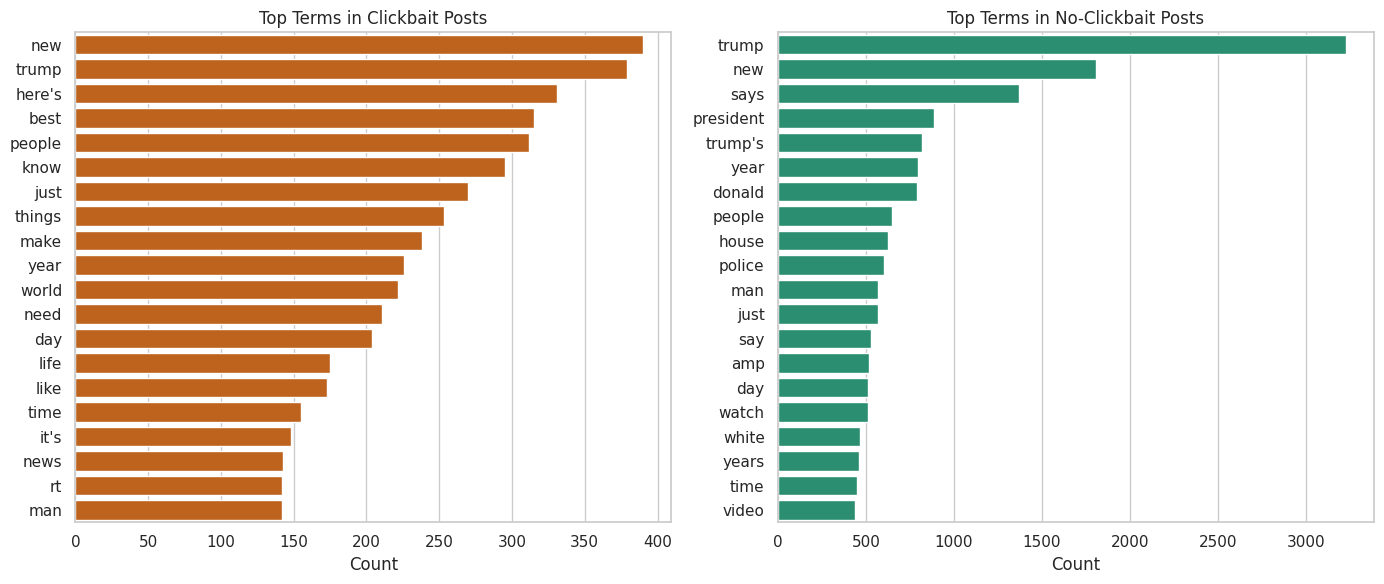

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

sns.barplot(data=clickbait_terms, y="term", x="count", ax=axes[0], color="#d95f02")
axes[0].set_title("Top Terms in Clickbait Posts")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(data=non_clickbait_terms, y="term", x="count", ax=axes[1], color="#1b9e77")
axes[1].set_title("Top Terms in No-Clickbait Posts")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. EDA Takeaways

The exploratory analysis suggests several important points for the modeling stage:

1. The `instances.jsonl` and `truth.jsonl` files can be reliably matched using `id`.
2. A binary clickbait label can be constructed from the median of `truthJudgments`, and this label matches the official `truthClass` field.
3. The data is moderately imbalanced, with no-clickbait posts representing the larger class.
4. The input text is short, which makes this a headline-style text classification problem.
5. A small number of records have empty `postText`, which should be handled before training.
6. Because of class imbalance, the modeling section should report F1 score, precision, recall, and confusion matrices in addition to accuracy.

The next step is to preprocess the text and build neural network models for binary classification.

## 8. Text Preprocessing for Neural Network Modeling

The exploratory analysis above showed that the model input is short post text. For the neural network baseline, we use the post text as the primary input feature and create a train/validation/test framework:

- `train1` and `train2` are combined as the development dataset.
- A stratified validation set is split from the combined training data.
- `test` is held out for final model evaluation only.

A small number of records have empty `postText`. Since the dataset also includes the linked article title, we use `targetTitle` as a fallback text field only when `postText` is empty. This keeps the observations in the dataset while preserving `postText` as the main input whenever available.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

model_df = all_df.copy()
model_df["model_text"] = model_df["text"]
empty_mask = model_df["model_text"].eq("")
model_df.loc[empty_mask, "model_text"] = model_df.loc[empty_mask, "target_title"].fillna("").str.strip()
model_df["model_text_is_fallback"] = empty_mask.astype(int)

# Drop any rows that are still empty after the fallback step.
model_df = model_df[model_df["model_text"].str.len() > 0].reset_index(drop=True)

train_dev_df = model_df[model_df["split"].isin(["train1", "train2"])].reset_index(drop=True)
final_test_df = model_df[model_df["split"].eq("test")].reset_index(drop=True)

print(f"Development rows from train1 + train2: {len(train_dev_df):,}")
print(f"Final test rows: {len(final_test_df):,}")
print(f"Rows using targetTitle fallback: {model_df['model_text_is_fallback'].sum():,}")

Development rows from train1 + train2: 21,997
Final test rows: 18,979
Rows using targetTitle fallback: 120


In [ ]:
train_split_df, val_split_df = train_test_split(
    train_dev_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_dev_df["label"],
)

X_train = train_split_df["model_text"].astype(str).to_numpy()
y_train = train_split_df["label"].astype("int32").to_numpy()

X_val = val_split_df["model_text"].astype(str).to_numpy()
y_val = val_split_df["label"].astype("int32").to_numpy()

X_test = final_test_df["model_text"].astype(str).to_numpy()
y_test = final_test_df["label"].astype("int32").to_numpy()

split_model_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "clickbait_rows": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "clickbait_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})
split_model_summary["clickbait_rate"] = split_model_summary["clickbait_rate"].map(lambda x: f"{x:.2%}")
split_model_summary

,dataset,rows,clickbait_rows,clickbait_rate
0,train,17597,4418,25.11%
1,validation,4400,1105,25.11%
2,test,18979,4515,23.79%


Because the dataset is imbalanced, we compute class weights from the training split. These weights give more importance to the minority class during training and can help the model avoid simply favoring the no-clickbait class.

In [ ]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
class_weight

{0: 0.6676151453069277, 1: 1.9915119963784518}

## 9. Baseline Neural Network Model

The first neural network is intentionally simple. It establishes a baseline that later models can try to improve upon.

Architecture:

1. `TextVectorization`: converts raw text into integer token sequences.
2. `Embedding`: learns dense vector representations for tokens.
3. `GlobalAveragePooling1D`: averages token embeddings into one fixed-length vector per post.
4. `Dense` layers: classify the post as clickbait or no-clickbait.
5. `Sigmoid` output: produces a probability between 0 and 1.

This model is appropriate as a baseline because it is fast, interpretable at a high level, and uses neural network embeddings rather than manually engineered text features.

### 9.1 TensorFlow / Keras Setup

The course uses TensorFlow and Keras. If running this notebook in Google Colab, TensorFlow is usually already installed. If it is not available in the execution environment, install it before running the modeling cells.

In [ ]:
# If TensorFlow is not installed in your environment, uncomment the next line and restart the runtime if needed.
# %pip install -q tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
tf.keras.utils.set_random_seed(RANDOM_STATE)

TensorFlow version: 2.19.0


In [ ]:
MAX_TOKENS = 12000
SEQUENCE_LENGTH = 32
EMBEDDING_DIM = 64
BATCH_SIZE = 128
EPOCHS = 10

text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
)

text_vectorizer.adapt(X_train)

vocab = text_vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(vocab):,}")
print("First 20 vocabulary tokens:", vocab[:20])

# Diagnostic: rows that become all-zero after vectorization can create NaN values
# when mask_zero=True is combined with pooling layers. The models below therefore
# use mask_zero=False and we also report how often all-zero rows occur.
def vectorization_diagnostics(texts, name):
    token_ids = text_vectorizer(texts).numpy()
    all_zero = (token_ids.sum(axis=1) == 0)
    print(f"{name}: {all_zero.sum():,} all-zero vectorized rows out of {len(texts):,}")
    if all_zero.sum() > 0:
        example_idx = np.where(all_zero)[0][:5]
        display(pd.DataFrame({"example_text": np.array(texts)[example_idx]}))
    return all_zero

_ = vectorization_diagnostics(X_train, "Train")
_ = vectorization_diagnostics(X_val, "Validation")
_ = vectorization_diagnostics(X_test, "Test")

Vocabulary size: 12,000
First 20 vocabulary tokens: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('in'), np.str_('a'), np.str_('of'), np.str_('for'), np.str_('and'), np.str_('is'), np.str_('on'), np.str_('with'), np.str_('trump'), np.str_('at'), np.str_('are'), np.str_('new'), np.str_('you'), np.str_('this'), np.str_('from'), np.str_('after')]
Train: 2 all-zero vectorized rows out of 17,597


,example_text
0,...
1,...


Validation: 0 all-zero vectorized rows out of 4,400
Test: 6 all-zero vectorized rows out of 18,979


,example_text
0,...
1,...
2,...
3,...
4,...


In [ ]:
sample_texts = X_train[:3]
sample_tokens = text_vectorizer(sample_texts).numpy()

pd.DataFrame({
    "text": sample_texts,
    "vectorized_tokens": sample_tokens.tolist(),
})

,text,vectorized_tokens
0,"Little late on this one, don'cha think?","[480, 907, 10, 17, 51, 1, 199, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,A flight attendant’s jet lag survival guide,"[5, 364, 1, 3566, 1, 3412, 590, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,Facebook's quarterly earnings blow past Wall Street's expectations,"[4552, 7209, 2718, 3322, 643, 359, 2262, 3256, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


### 9.2 Build the Baseline Model

The model uses `binary_crossentropy` because the target variable is binary. We track accuracy for intuitive interpretation, but we also track AUC, precision, and recall because the dataset is imbalanced.

In [ ]:
def build_baseline_model():
    inputs = keras.Input(shape=(1,), dtype=tf.string, name="post_text")
    x = text_vectorizer(inputs)
    x = layers.Embedding(
        input_dim=len(vocab),
        output_dim=EMBEDDING_DIM,
        mask_zero=False,
        name="token_embedding",
    )(x)
    x = layers.GlobalAveragePooling1D(name="average_embedding_pooling")(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="clickbait_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="baseline_embedding_classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "baseline_embedding_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ post_text (InputLayer)          │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 32, 64)         │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_embedding_pooling       │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clickbait_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,225 (2.95 MB)

 Trainable params: 772,225 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

### 9.3 Train the Baseline Model

Early stopping monitors validation loss and restores the best weights. This reduces the risk of overfitting, especially because headline texts are short and the model may quickly memorize frequent phrases.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
)

terminate_on_nan = keras.callbacks.TerminateOnNaN()

history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr, terminate_on_nan],
    verbose=1,
)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5471 - auc: 0.6770 - loss: 0.6656 - precision: 0.3252 - recall: 0.7474 - val_accuracy: 0.6639 - val_auc: 0.7932 - val_loss: 0.6167 - val_precision: 0.4125 - val_recall: 0.7982 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7598 - auc: 0.8359 - loss: 0.5122 - precision: 0.5144 - recall: 0.7727 - val_accuracy: 0.7802 - val_auc: 0.8441 - val_loss: 0.4818 - val_precision: 0.5448 - val_recall: 0.7593 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8106 - auc: 0.8874 - loss: 0.4260 - precision: 0.5884 - recall: 0.8173 - val_accuracy: 0.8030 - val_auc: 0.8529 - val_loss: 0.4358 - val_precision: 0.5893 - val_recall: 0.7104 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8433 - auc: 0.9177 - loss: 0.3653 - precision: 0.6404 - recall: 0.8569 - val_accuracy: 0.7959 - val_auc: 0.8512 - val_loss: 0.4463 -

### 9.4 Training Curves

The plots below compare training and validation performance across epochs. A large gap between training and validation curves would suggest overfitting.

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.547139,0.676995,0.665629,0.325160,0.747397,0.663864,0.793222,0.616687,0.412535,0.798190,0.0010
1,0.759789,0.835885,0.512237,0.514389,0.772748,0.780227,0.844106,0.481785,0.544805,0.759276,0.0010
2,0.810593,0.887442,0.425978,0.588398,0.817338,0.802955,0.852862,0.435826,0.589339,0.710407,0.0010
3,0.843269,0.917715,0.365346,0.640392,0.856949,0.795909,0.851162,0.446296,0.575713,0.712217,0.0010
4,0.868784,0.938547,0.315853,0.683296,0.889769,0.771591,0.848288,0.502173,0.531486,0.763801,0.0005


History keys: ['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate']


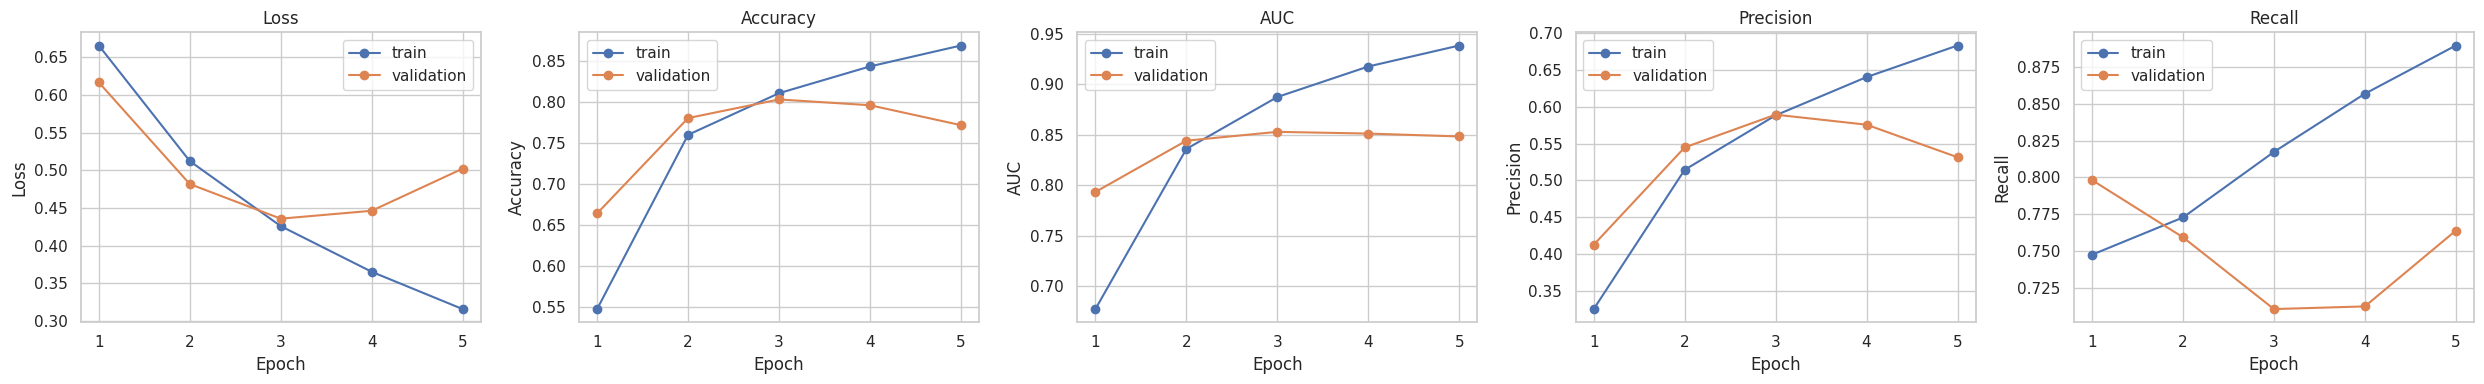

In [ ]:
def plot_training_history(history):
    """Plot training curves using the metric keys actually returned by Keras."""
    history_df = pd.DataFrame(history.history)
    display(history_df)
    print("History keys:", list(history_df.columns))

    preferred_pairs = [
        ("loss", "val_loss", "Loss"),
        ("accuracy", "val_accuracy", "Accuracy"),
        ("auc", "val_auc", "AUC"),
        ("precision", "val_precision", "Precision"),
        ("recall", "val_recall", "Recall"),
    ]

    available_pairs = [
        pair for pair in preferred_pairs
        if pair[0] in history_df.columns and pair[1] in history_df.columns
    ]

    if not available_pairs:
        print("No matching train/validation metric pairs were found to plot.")
        return history_df

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(5 * len(available_pairs), 4))
    if len(available_pairs) == 1:
        axes = [axes]

    for ax, (train_metric, val_metric, title) in zip(axes, available_pairs):
        ax.plot(history_df.index + 1, history_df[train_metric], marker="o", label="train")
        ax.plot(history_df.index + 1, history_df[val_metric], marker="o", label="validation")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.legend()

    plt.tight_layout()
    plt.show()
    return history_df

baseline_history_df = plot_training_history(history)

## 10. Baseline Model Evaluation

After model selection using the validation set, we evaluate the final baseline model on the held-out test set. This test set was not used during training or validation.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Use return_dict=True because recent Keras versions may return metrics_names that do not
# have the same length as the raw evaluate() list.
baseline_test_metrics = baseline_model.evaluate(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0,
    return_dict=True,
)

pd.DataFrame(
    baseline_test_metrics.items(),
    columns=["metric", "value"],
).sort_values("metric").reset_index(drop=True)

,metric,value
0,accuracy,0.815270
1,auc,0.872460
2,loss,0.416682
3,precision,0.585668
4,recall,0.763898


In [ ]:
def validate_prediction_probabilities(probabilities, model_name):
    """Stop with a clear message if a model produced NaN or infinite probabilities."""
    probabilities = np.asarray(probabilities)
    bad_mask = ~np.isfinite(probabilities)
    if bad_mask.any():
        bad_count = int(bad_mask.sum())
        raise ValueError(
            f"{model_name} produced {bad_count} NaN or infinite predicted probabilities. "
            "Rerun the TextVectorization cell and rebuild/retrain the model after the mask_zero=False fix."
        )
    return probabilities


y_test_prob = baseline_model.predict(X_test, batch_size=BATCH_SIZE).ravel()
y_test_prob = validate_prediction_probabilities(y_test_prob, "Baseline model")
y_test_pred = (y_test_prob >= 0.5).astype(int)

baseline_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_prob),
    ],
})
baseline_summary["value"] = baseline_summary["value"].round(4)
baseline_summary

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,metric,value
0,accuracy,0.8153
1,precision,0.5857
2,recall,0.7639
3,f1,0.6630
4,roc_auc,0.8725


In [ ]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["no-clickbait", "clickbait"],
    zero_division=0,
))

              precision    recall  f1-score   support

no-clickbait       0.92      0.83      0.87     14464
   clickbait       0.59      0.76      0.66      4515

    accuracy                           0.82     18979
   macro avg       0.75      0.80      0.77     18979
weighted avg       0.84      0.82      0.82     18979



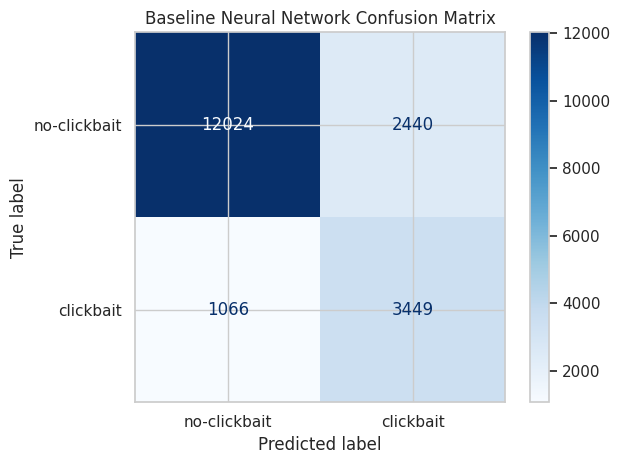

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no-clickbait", "clickbait"])

disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

### 10.1 Error Analysis

The next cells inspect false positives and false negatives. This helps us understand what kinds of posts the baseline model confuses.

- **False positives:** posts predicted as clickbait but labeled no-clickbait.
- **False negatives:** posts predicted as no-clickbait but labeled clickbait.

In [ ]:
error_analysis_df = final_test_df.copy()
error_analysis_df["predicted_probability"] = y_test_prob
error_analysis_df["predicted_label"] = y_test_pred
error_analysis_df["predicted_class"] = np.where(error_analysis_df["predicted_label"].eq(1), "clickbait", "no-clickbait")
error_analysis_df["actual_class"] = np.where(error_analysis_df["label"].eq(1), "clickbait", "no-clickbait")
error_analysis_df["correct"] = error_analysis_df["predicted_label"].eq(error_analysis_df["label"])

false_positives = (
    error_analysis_df[(error_analysis_df["label"] == 0) & (error_analysis_df["predicted_label"] == 1)]
    .sort_values("predicted_probability", ascending=False)
)

false_negatives = (
    error_analysis_df[(error_analysis_df["label"] == 1) & (error_analysis_df["predicted_label"] == 0)]
    .sort_values("predicted_probability", ascending=True)
)

print(f"False positives: {len(false_positives):,}")
print(f"False negatives: {len(false_negatives):,}")

False positives: 2,440
False negatives: 1,066


In [ ]:
false_positives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
17498,no-clickbait,clickbait,0.973430,0.466667,Why you should let a stranger choose your Facebook profile picture for you
14077,no-clickbait,clickbait,0.972060,0.200000,Here's how Apple will handle things if your MacBook is damaged in your checked luggage
3171,no-clickbait,clickbait,0.971469,0.533333,How well do you remember Love Actually? Take the quiz and find out
8692,no-clickbait,clickbait,0.969481,0.333333,Entrepreneurs: how you know if you need a cofounder to build your startup:
10905,no-clickbait,clickbait,0.968588,0.266667,"So, how do you, like, um, stop using verbal fillers that can make you sound, you know, nervous or not so smart?"
4106,no-clickbait,clickbait,0.967793,0.133333,"""No one is going to pay you what you deserve if you don’t believe in your value."""
15480,no-clickbait,clickbait,0.961308,0.400000,"These dogs just had a stunning engagement shoot, and you can't get a text back"
2474,no-clickbait,clickbait,0.960453,0.600000,The 50 most hilarious tweets from parents this year
17483,no-clickbait,clickbait,0.958159,0.333333,He's how tall?! Some things you should know about April the giraffe's newborn calf
6177,no-clickbait,clickbait,0.956869,0.533333,CargillVoice: 5 things you need to know about food banks


In [ ]:
false_negatives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
16513,clickbait,no-clickbait,0.011680,0.800000,Swedish Police Chief Shut Down By Interior Minister After Call to Deport Terror Suspects
16006,clickbait,no-clickbait,0.014805,0.666667,"Capitol Hill Source: Intel Chair Nunes Temporarily Stepped Down from Russia Probe to Keep Focus on Russia, Unmasking Scandal"
10924,clickbait,no-clickbait,0.017533,0.800000,🔥 🔥 Send in a BERN UNIT because Bernie Sanders just poured hotfire BERN SAUCE all over Trump with epic BERN 🔥 🔥
16244,clickbait,no-clickbait,0.018013,0.733333,PolitiFact Pulls 2014 ‘Mostly True’ Rating of John Kerry’s Claim of Eliminating Syrian Chemical Weapons
16131,clickbait,no-clickbait,0.018752,1.000000,Trump: It Is In ‘Vital National Security Interest of the US’ to Prevent the Use of Chemical Weapons
9387,clickbait,no-clickbait,0.019573,0.400000,Federal Government moves to change Native Title Act after shock court ruling #auspol
4736,clickbait,no-clickbait,0.025955,0.533333,See inside the $5.5 million mansion Ivanka Trump and Jared Kushner will reportedly move into
15696,clickbait,no-clickbait,0.030181,0.800000,Meadows: Freedom Caucus Intrigued at Healthcare Offer After Hill Meeting with Pence
17782,clickbait,no-clickbait,0.030330,0.533333,Bruce Springsteen has new music out and it's taking aim at President Trump
16634,clickbait,no-clickbait,0.032933,0.866667,Crackdown: AG Sessions Vows ‘New Era’ at Southern Border


## 11. Baseline Modeling Takeaways

This baseline neural network provides the first benchmark for clickbait detection using only text from the online post. It uses learned word embeddings and a simple pooling architecture, which makes it a useful starting point for comparison.

In the next modeling stage, we can try to improve performance by using a sequence-aware architecture such as a bidirectional LSTM or GRU, a 1D convolutional neural network for text, or pretrained word embeddings. Since the dataset is imbalanced, future models should continue to compare precision, recall, F1 score, ROC-AUC, and confusion matrices rather than relying only on accuracy.

## 12. Improved Model: Sequence-Aware Bidirectional LSTM

The baseline model treats a post as a bag-like average of learned word embeddings. This is useful as a first benchmark, but it loses much of the word-order information in the headline. Clickbait often depends on phrasing, suspense, or incomplete information, such as "you won't believe," "this is why," or question-style constructions. These patterns are partly sequential.

To add more modeling depth, we train a **Bidirectional LSTM** model. The goal is not only to increase model complexity, but to test whether sequence-aware neural network architecture improves clickbait detection.

Why a Bidirectional LSTM is appropriate here:

1. Headlines and posts are short sequences of words.
2. Clickbait cues may depend on the order and combination of words.
3. A bidirectional layer can read context from both directions.
4. The model is still lightweight enough for this dataset and course project.

We keep the same train/validation/test split and the same `TextVectorization` layer used in the baseline model. This makes the comparison fair because both models receive the same text input representation.

### 12.1 Build the Improved Model

Compared with the baseline model, this architecture includes:

- `Embedding`: learns token representations.
- `Bidirectional LSTM`: captures sequential patterns in both forward and backward directions.
- `GlobalMaxPooling1D`: focuses on the strongest learned sequence signals.
- `BatchNormalization` and `Dropout`: reduce overfitting and stabilize training.
- `Sigmoid` output: returns clickbait probability.

Because the dataset is moderately imbalanced, we continue to use class weights during training.

In [ ]:
def build_bilstm_model():
    inputs = keras.Input(shape=(1,), dtype=tf.string, name="post_text")
    x = text_vectorizer(inputs)

    x = layers.Embedding(
        input_dim=len(vocab),
        output_dim=EMBEDDING_DIM,
        mask_zero=False,
        name="token_embedding",
    )(x)
    x = layers.SpatialDropout1D(0.20)(x)
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.20, recurrent_dropout=0.0),
        name="bidirectional_lstm",
    )(x)
    x = layers.GlobalMaxPooling1D(name="global_max_pooling")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="clickbait_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="improved_bilstm_classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7.5e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

bilstm_model = build_bilstm_model()
bilstm_model.summary()

Model: "improved_bilstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ post_text (InputLayer)          │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 32, 64)         │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 32, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 32, 128)        │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clickbait_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,881 (3.22 MB)

 Trainable params: 842,625 (3.21 MB)

 Non-trainable params: 256 (1.00 KB)

### 12.2 Train the Improved Model

We use early stopping again, but allow a slightly longer patience because sequence models may need more epochs to converge than the baseline pooling model.

In [ ]:
bilstm_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

bilstm_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
)

bilstm_terminate_on_nan = keras.callbacks.TerminateOnNaN()

bilstm_history = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[bilstm_early_stopping, bilstm_reduce_lr, bilstm_terminate_on_nan],
    verbose=1,
)

Epoch 1/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.6934 - auc: 0.7722 - loss: 0.5696 - precision: 0.4316 - recall: 0.6974 - val_accuracy: 0.7502 - val_auc: 0.8504 - val_loss: 0.5853 - val_precision: 1.0000 - val_recall: 0.0054 - learning_rate: 7.5000e-04
Epoch 2/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - accuracy: 0.8168 - auc: 0.9012 - loss: 0.3991 - precision: 0.5967 - recall: 0.8345 - val_accuracy: 0.7702 - val_auc: 0.8479 - val_loss: 0.4887 - val_precision: 0.8983 - val_recall: 0.0959 - learning_rate: 7.5000e-04
Epoch 3/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.8612 - auc: 0.9427 - loss: 0.3038 - precision: 0.6648 - recall: 0.9020 - val_accuracy: 0.8145 - val_auc: 0.8371 - val_loss: 0.4226 - val_precision: 0.7661 - val_recall: 0.3765 - learning_rate: 7.5000e-04
Epoch 4/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 0.8925 - auc: 0.9642 - loss: 0.2340 - precision: 0.7197 - recall: 0.9368 - val_accuracy: 0.8009 - val_auc: 0.8239 

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.693414,0.772241,0.569623,0.431573,0.697374,0.750227,0.850436,0.585325,1.000000,0.005430,0.000750
1,0.816844,0.901237,0.399136,0.596699,0.834540,0.770227,0.847909,0.488696,0.898305,0.095928,0.000750
2,0.861226,0.942702,0.303824,0.664832,0.901992,0.814545,0.837138,0.422588,0.766114,0.376471,0.000750
3,0.892538,0.964175,0.233958,0.719701,0.936849,0.800909,0.823859,0.476369,0.626240,0.514027,0.000750
4,0.931352,0.982526,0.155495,0.799776,0.969217,0.795227,0.811572,0.644086,0.599804,0.554751,0.000375
5,0.948741,0.987921,0.123589,0.842290,0.979176,0.788636,0.804027,0.749989,0.576286,0.598190,0.000188


History keys: ['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate']


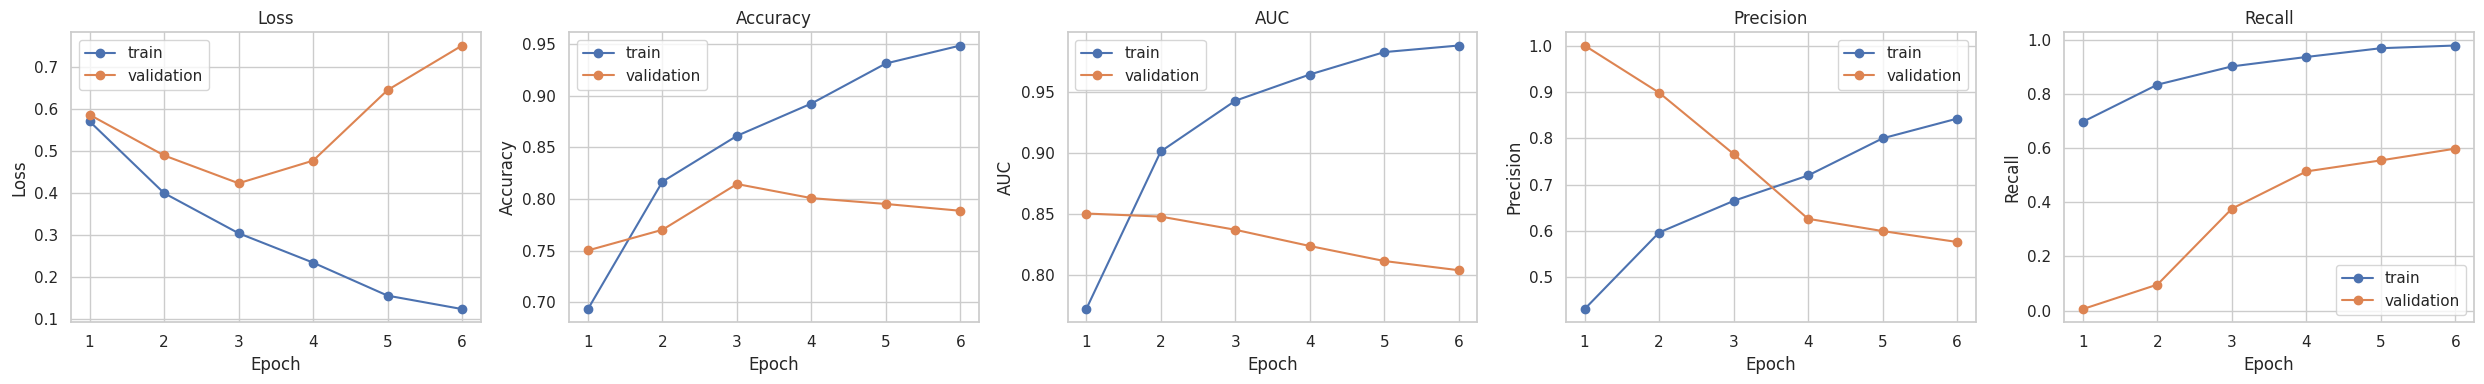

In [ ]:
bilstm_history_df = plot_training_history(bilstm_history)

## 13. Threshold Tuning for Business Use

The default classification threshold is `0.50`: if the predicted clickbait probability is at least 0.50, the model predicts clickbait. However, in a business setting, the best threshold depends on the cost of different mistakes.

For example:

- A **false positive** may unfairly flag a legitimate headline as clickbait.
- A **false negative** may allow misleading clickbait content to remain visible.

Because the dataset is imbalanced and the business tradeoff matters, we tune the threshold on the validation set by maximizing F1 score. This makes the modeling process more thoughtful than simply accepting the default threshold.

In [ ]:
from sklearn.metrics import precision_recall_curve

val_prob_bilstm = bilstm_model.predict(X_val, batch_size=BATCH_SIZE).ravel()
val_prob_bilstm = validate_prediction_probabilities(val_prob_bilstm, "BiLSTM validation predictions")
precision_vals, recall_vals, threshold_vals = precision_recall_curve(y_val, val_prob_bilstm)

threshold_eval = pd.DataFrame({
    "threshold": threshold_vals,
    "precision": precision_vals[:-1],
    "recall": recall_vals[:-1],
})
threshold_eval["f1"] = (
    2 * threshold_eval["precision"] * threshold_eval["recall"] /
    (threshold_eval["precision"] + threshold_eval["recall"] + 1e-8)
)

best_threshold_row = threshold_eval.sort_values("f1", ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

best_threshold_row.to_frame().T

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


,threshold,precision,recall,f1
3043,0.23367,0.570579,0.695023,0.626683


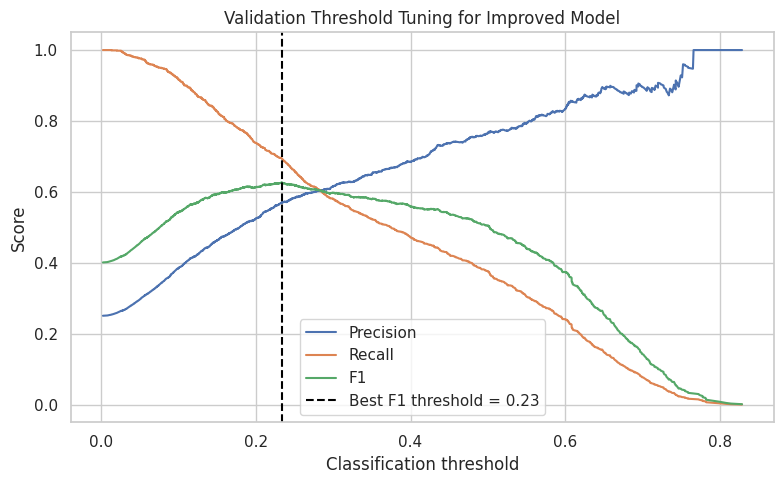

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_eval["threshold"], threshold_eval["precision"], label="Precision")
plt.plot(threshold_eval["threshold"], threshold_eval["recall"], label="Recall")
plt.plot(threshold_eval["threshold"], threshold_eval["f1"], label="F1")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best F1 threshold = {best_threshold:.2f}")
plt.title("Validation Threshold Tuning for Improved Model")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Improved Model Evaluation on the Held-Out Test Set

After selecting the improved architecture and tuning the threshold using the validation set, we evaluate the model on the held-out test set. The test set remains untouched until this final evaluation step.

In [ ]:
bilstm_test_metrics = bilstm_model.evaluate(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0,
    return_dict=True,
)

pd.DataFrame(
    bilstm_test_metrics.items(),
    columns=["metric", "value"],
).sort_values("metric").reset_index(drop=True)

,metric,value
0,accuracy,0.830233
1,auc,0.856499
2,loss,0.390641
3,precision,0.775693
4,recall,0.402879


In [ ]:
y_test_prob_bilstm = bilstm_model.predict(X_test, batch_size=BATCH_SIZE).ravel()
y_test_prob_bilstm = validate_prediction_probabilities(y_test_prob_bilstm, "BiLSTM test predictions")
y_test_pred_bilstm_default = (y_test_prob_bilstm >= 0.50).astype(int)
y_test_pred_bilstm_tuned = (y_test_prob_bilstm >= best_threshold).astype(int)

bilstm_comparison = pd.DataFrame({
    "model": ["BiLSTM default threshold", "BiLSTM tuned threshold"],
    "threshold": [0.50, best_threshold],
    "accuracy": [
        accuracy_score(y_test, y_test_pred_bilstm_default),
        accuracy_score(y_test, y_test_pred_bilstm_tuned),
    ],
    "precision": [
        precision_score(y_test, y_test_pred_bilstm_default, zero_division=0),
        precision_score(y_test, y_test_pred_bilstm_tuned, zero_division=0),
    ],
    "recall": [
        recall_score(y_test, y_test_pred_bilstm_default, zero_division=0),
        recall_score(y_test, y_test_pred_bilstm_tuned, zero_division=0),
    ],
    "f1": [
        f1_score(y_test, y_test_pred_bilstm_default, zero_division=0),
        f1_score(y_test, y_test_pred_bilstm_tuned, zero_division=0),
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_test_prob_bilstm),
        roc_auc_score(y_test, y_test_prob_bilstm),
    ],
})

for col in ["threshold", "accuracy", "precision", "recall", "f1", "roc_auc"]:
    bilstm_comparison[col] = bilstm_comparison[col].round(4)

bilstm_comparison

149/149 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step


,model,threshold,accuracy,precision,recall,f1,roc_auc
0,BiLSTM default threshold,0.5000,0.8302,0.7757,0.4029,0.5303,0.8566
1,BiLSTM tuned threshold,0.2337,0.8013,0.5621,0.7444,0.6406,0.8566


In [ ]:
print("BiLSTM with tuned threshold")
print(classification_report(
    y_test,
    y_test_pred_bilstm_tuned,
    target_names=["no-clickbait", "clickbait"],
    zero_division=0,
))

BiLSTM with tuned threshold
              precision    recall  f1-score   support

no-clickbait       0.91      0.82      0.86     14464
   clickbait       0.56      0.74      0.64      4515

    accuracy                           0.80     18979
   macro avg       0.74      0.78      0.75     18979
weighted avg       0.83      0.80      0.81     18979



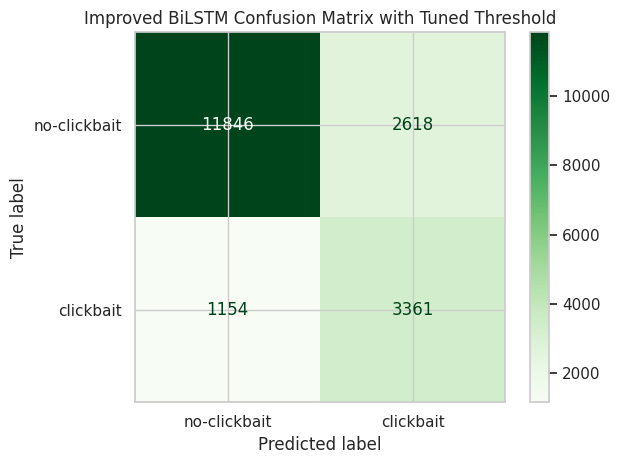

In [ ]:
cm_bilstm = confusion_matrix(y_test, y_test_pred_bilstm_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bilstm, display_labels=["no-clickbait", "clickbait"])

disp.plot(cmap="Greens", values_format="d")
plt.title("Improved BiLSTM Confusion Matrix with Tuned Threshold")
plt.tight_layout()
plt.show()

## 15. Baseline vs. Improved Model Comparison

The table below compares the baseline embedding model with the improved BiLSTM model. The most important metric for this project is F1 score because it balances precision and recall for the clickbait class.

Accuracy is still useful, but it can be misleading when no-clickbait examples are more common than clickbait examples.

In [ ]:
model_comparison = pd.concat([
    baseline_summary.assign(model="Baseline embedding model", threshold=0.50)
        .pivot_table(index=["model", "threshold"], columns="metric", values="value")
        .reset_index(),
    bilstm_comparison[bilstm_comparison["model"].eq("BiLSTM tuned threshold")]
        .rename(columns={"model": "model"}),
], ignore_index=True, sort=False)

comparison_columns = ["model", "threshold", "accuracy", "precision", "recall", "f1", "roc_auc"]
model_comparison = model_comparison[comparison_columns]
model_comparison

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Baseline embedding model,0.5000,0.8153,0.5857,0.7639,0.6630,0.8725
1,BiLSTM tuned threshold,0.2337,0.8013,0.5621,0.7444,0.6406,0.8566


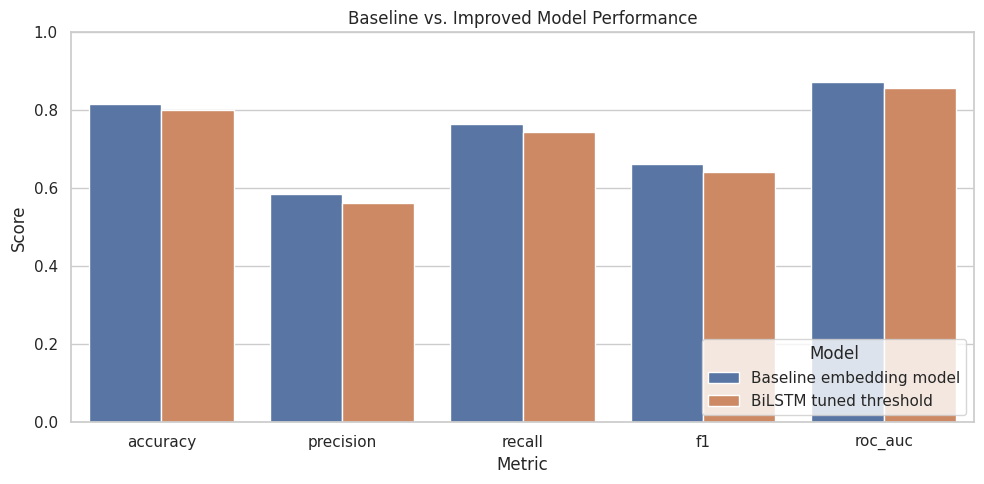

In [ ]:
comparison_long = model_comparison.melt(
    id_vars=["model", "threshold"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_long, x="metric", y="score", hue="model")
plt.title("Baseline vs. Improved Model Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

## 16. Improved Model Error Analysis

We examine the most confident errors from the improved model. These cases are useful because they show where the model may have learned misleading patterns or where the label itself may be ambiguous.

In [ ]:
bilstm_error_df = final_test_df.copy()
bilstm_error_df["predicted_probability"] = y_test_prob_bilstm
bilstm_error_df["predicted_label"] = y_test_pred_bilstm_tuned
bilstm_error_df["predicted_class"] = np.where(bilstm_error_df["predicted_label"].eq(1), "clickbait", "no-clickbait")
bilstm_error_df["actual_class"] = np.where(bilstm_error_df["label"].eq(1), "clickbait", "no-clickbait")
bilstm_error_df["correct"] = bilstm_error_df["predicted_label"].eq(bilstm_error_df["label"])

bilstm_false_positives = (
    bilstm_error_df[(bilstm_error_df["label"] == 0) & (bilstm_error_df["predicted_label"] == 1)]
    .sort_values("predicted_probability", ascending=False)
)

bilstm_false_negatives = (
    bilstm_error_df[(bilstm_error_df["label"] == 1) & (bilstm_error_df["predicted_label"] == 0)]
    .sort_values("predicted_probability", ascending=True)
)

print(f"BiLSTM false positives: {len(bilstm_false_positives):,}")
print(f"BiLSTM false negatives: {len(bilstm_false_negatives):,}")

BiLSTM false positives: 2,618
BiLSTM false negatives: 1,154


In [ ]:
bilstm_false_positives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
8298,no-clickbait,clickbait,0.819500,0.400000,Literally just 18 really cute and wholesome Tumblr posts
8343,no-clickbait,clickbait,0.789893,0.600000,10 shocking confessions from nannies
17617,no-clickbait,clickbait,0.780057,0.400000,People imagine what would happen #IfOnlytheEarthCouldSpeak
3592,no-clickbait,clickbait,0.760718,0.333333,7 features we'll probably see in Tesla's mysterious 'Model Y'
2474,no-clickbait,clickbait,0.756428,0.600000,The 50 most hilarious tweets from parents this year
18259,no-clickbait,clickbait,0.752363,0.400000,What to cook this week
2620,no-clickbait,clickbait,0.750314,0.466667,Here's how much legroom you get on America's airlines
12823,no-clickbait,clickbait,0.749621,0.466667,7 times @CarrieUnderwood's faith was inspiring ❤️
8403,no-clickbait,clickbait,0.749074,0.266667,What's your answer to @KatrinaPierson's question?
11632,no-clickbait,clickbait,0.747821,0.400000,These countries are getting more miserable this year


In [ ]:
bilstm_false_negatives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
11425,clickbait,no-clickbait,0.011126,0.666667,Quarter-million-pound mouse delays British Airways California flight
6922,clickbait,no-clickbait,0.011345,0.600000,Economic Scene: Mexico’s Potential Weapons if Trump Declares War on Nafta
7033,clickbait,no-clickbait,0.011709,0.533333,Catholic Church is 'full of s**t' declares Philippines president Duterte
16006,clickbait,no-clickbait,0.011938,0.666667,"Capitol Hill Source: Intel Chair Nunes Temporarily Stepped Down from Russia Probe to Keep Focus on Russia, Unmasking Scandal"
12447,clickbait,no-clickbait,0.012484,0.466667,"Samsung heir denies charges as ""trial of the century"" begins"
1242,clickbait,no-clickbait,0.013290,0.600000,"Improve smartphone voice recognition? There’s a $10,000 prize for that. Design a delivery drone? $50,000."
7914,clickbait,no-clickbait,0.013823,0.666667,Julio Jones ... Cam Newton ... Adrian Peterson ... Not all 5-star recruits work out. These 20 did. Let's rank 'em:
8607,clickbait,no-clickbait,0.015079,0.533333,"Mixed message: 84 Lumber's Super Bowl ad spurs outrage, confusion via @brookefoxnews"
16744,clickbait,no-clickbait,0.015377,0.933333,Crackdown: AG Sessions Vows ‘New Era’ at Southern Border
16634,clickbait,no-clickbait,0.015377,0.866667,Crackdown: AG Sessions Vows ‘New Era’ at Southern Border


## 17. Interpretation and Next Steps

The improved BiLSTM model adds sequence awareness to the baseline neural network. This reflects a more realistic modeling assumption for clickbait detection: word order and phrasing can matter, not only the presence of individual words.

The threshold-tuning step also connects the model to the business problem. A platform may choose a higher threshold if it wants to avoid incorrectly penalizing legitimate headlines, or a lower threshold if it wants to aggressively reduce clickbait exposure. In this notebook, we tune the threshold to maximize validation F1 score, which balances precision and recall.

Potential next steps include:

1. Testing a 1D CNN text model to capture local phrase patterns.
2. Using pretrained word embeddings such as GloVe to incorporate broader semantic knowledge.
3. Fine-tuning a transformer model such as BERT if computational resources allow.
4. Adding article metadata or target title information as additional model inputs.
5. Calibrating predicted probabilities before using them in a production ranking or moderation system.

## 18. Final Results Summary

This section summarizes the project results after training and evaluating the baseline and improved neural network models. The final comparison focuses on metrics that are appropriate for an imbalanced binary classification problem.

For this project, **F1 score** is especially important because it balances precision and recall for the clickbait class. A model with high precision but low recall may miss many clickbait posts, while a model with high recall but low precision may incorrectly flag too many legitimate posts. In a platform setting, the preferred tradeoff depends on the business goal.

In [ ]:
final_results = model_comparison.copy()
final_results = final_results.sort_values("f1", ascending=False).reset_index(drop=True)
final_results

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Baseline embedding model,0.5000,0.8153,0.5857,0.7639,0.6630,0.8725
1,BiLSTM tuned threshold,0.2337,0.8013,0.5621,0.7444,0.6406,0.8566


In [ ]:
best_model = final_results.iloc[0]

print("Best-performing model by F1 score")
print("Model:", best_model["model"])
print("Threshold:", best_model["threshold"])
print("Accuracy:", best_model["accuracy"])
print("Precision:", best_model["precision"])
print("Recall:", best_model["recall"])
print("F1:", best_model["f1"])
print("ROC-AUC:", best_model["roc_auc"])

Best-performing model by F1 score
Model: Baseline embedding model
Threshold: 0.5
Accuracy: 0.8153
Precision: 0.5857
Recall: 0.7639
F1: 0.663
ROC-AUC: 0.8725


## 19. Business Interpretation

The model can support a digital platform, publisher, or content moderation team by assigning each post a clickbait probability. This probability does not need to be used as an automatic removal decision. Instead, it can be integrated into a broader content quality workflow.

Possible business uses include:

1. **Ranking adjustment:** reduce the ranking weight of posts with high clickbait probability.
2. **Editorial review:** flag high-risk headlines for human review before publication.
3. **Creator feedback:** warn authors when a headline appears overly clickbait-like.
4. **Trust and safety analytics:** monitor trends in clickbait prevalence by publisher, topic, or time period.
5. **A/B testing:** evaluate whether reducing clickbait exposure improves long-term user trust and engagement.

The threshold-tuning section shows that the model can be adjusted for different business objectives. If the platform wants to avoid unfairly penalizing legitimate headlines, it can use a higher threshold. If the platform wants to aggressively reduce clickbait exposure, it can use a lower threshold.

In [ ]:
decision_policy = pd.DataFrame({
    "predicted_clickbait_probability": ["0.00 - 0.30", "0.30 - 0.60", "0.60 - 0.80", "0.80 - 1.00"],
    "risk_level": ["Low", "Moderate", "High", "Very high"],
    "possible_action": [
        "No action; normal ranking",
        "Monitor or lightly reduce ranking weight",
        "Flag for editorial review or reduce ranking weight",
        "Prioritize for review; consider stronger ranking penalty",
    ],
})

decision_policy

,predicted_clickbait_probability,risk_level,possible_action
0,0.00 - 0.30,Low,No action; normal ranking
1,0.30 - 0.60,Moderate,Monitor or lightly reduce ranking weight
2,0.60 - 0.80,High,Flag for editorial review or reduce ranking weight
3,0.80 - 1.00,Very high,Prioritize for review; consider stronger ranking penalty


## 20. Limitations

The project provides a useful neural network approach to clickbait detection, but there are several limitations:

1. **Text-only input:** the main models use post text only. Some clickbait signals may come from images, article content, publisher identity, or context.
2. **Historical data:** the dataset was collected from 2016-2017, so current headline styles may differ.
3. **Annotation ambiguity:** clickbait is partly subjective. Some posts may be borderline cases even for human annotators.
4. **Short text:** headlines and social posts contain limited context, which makes classification harder.
5. **Platform consequences:** an automated model could affect publishers unfairly if used without human oversight or calibration.

These limitations suggest that a production system should treat the model as a decision-support tool rather than a fully automated enforcement system.

## 21. Future Improvements

Several extensions could improve the model and deepen the analysis:

1. **Pretrained word embeddings:** use GloVe or fastText embeddings to bring in semantic knowledge from larger corpora.
2. **Transformer-based model:** fine-tune a model such as BERT or DistilBERT for clickbait classification.
3. **Multi-input architecture:** combine `postText` with `targetTitle`, article descriptions, media indicators, and publisher metadata.
4. **Probability calibration:** calibrate predicted probabilities before using them in ranking or moderation decisions.
5. **Fairness and publisher analysis:** check whether the model over-flags particular publishers or content categories.
6. **Cost-sensitive thresholding:** choose thresholds based on estimated business costs of false positives and false negatives.
7. **Temporal validation:** train on older posts and test on newer posts to better simulate real deployment.

These improvements would help move the project from a course prototype toward a more realistic business analytics system.

## 22. Export Final Outputs

The following cells export the most important results from the notebook. These files can be used when preparing the final presentation slides and speaker notes.

In [ ]:
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

final_results.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
decision_policy.to_csv(OUTPUT_DIR / "business_decision_policy.csv", index=False)

final_predictions = bilstm_error_df[[
    "id",
    "model_text",
    "actual_class",
    "predicted_class",
    "predicted_probability",
    "truth_mean",
    "truth_median",
    "correct",
]].copy()

final_predictions.to_csv(OUTPUT_DIR / "improved_model_test_predictions.csv", index=False)

bilstm_false_positives[[
    "id", "model_text", "actual_class", "predicted_class", "predicted_probability", "truth_mean", "truth_median"
]].head(25).to_csv(OUTPUT_DIR / "top_false_positives.csv", index=False)

bilstm_false_negatives[[
    "id", "model_text", "actual_class", "predicted_class", "predicted_probability", "truth_mean", "truth_median"
]].head(25).to_csv(OUTPUT_DIR / "top_false_negatives.csv", index=False)

print("Exported files:")
for file_path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file_path)

Exported files:
- /content/BA865_clickbait_data/outputs/business_decision_policy.csv
- /content/BA865_clickbait_data/outputs/improved_model_test_predictions.csv
- /content/BA865_clickbait_data/outputs/model_comparison.csv
- /content/BA865_clickbait_data/outputs/top_false_negatives.csv
- /content/BA865_clickbait_data/outputs/top_false_positives.csv


## 23. Final Conclusion

This project demonstrates how neural networks can be used to detect clickbait in online headlines and social media posts. The workflow begins by matching input records from `instances.jsonl` with human annotation records from `truth.jsonl`, then constructs a binary label from the median of five `truthJudgments` scores.

The baseline neural network uses learned embeddings and average pooling to classify short text. The improved Bidirectional LSTM model adds sequence awareness, which is better aligned with the linguistic nature of clickbait. The final evaluation compares models using accuracy, precision, recall, F1 score, ROC-AUC, and confusion matrices, with special attention to the imbalanced nature of the dataset.

From a business perspective, the model is most useful as a decision-support system. Rather than automatically removing content, a platform could use predicted clickbait probability to support ranking, review, and editorial feedback workflows. The threshold can be adjusted depending on whether the business prioritizes reducing clickbait exposure or avoiding incorrect penalties for legitimate content.

## 24. Project Rubric Checklist

This notebook addresses the major code rubric requirements:

- Public dataset imported from local JSONL files derived from the Webis Clickbait Corpus 2017.
- Input features and labels matched using `id`.
- Text preprocessing and label construction implemented.
- Descriptive statistics and class balance analysis provided.
- Train/validation/test framework used.
- Baseline neural network architecture implemented with Keras.
- Improved sequence-aware neural network architecture implemented with Keras.
- Appropriate loss function and metrics used for binary classification.
- Final performance evaluated on a held-out test set.
- Error analysis included for false positives and false negatives.
- Business implications, limitations, and future improvements discussed.

## 25. Interactive Classroom Demo

For a more intuitive classroom presentation, the following cells create a small interactive demo. After the improved BiLSTM model has been trained, type any headline or post text into the box and click **Predict**. The widget returns the predicted clickbait probability and the final class decision.

This demo uses the same trained model and threshold selected earlier in the notebook.

In [ ]:
def predict_clickbait_post(post_text, threshold=None):
    """Predict whether a single post text is clickbait using the trained improved model."""
    if "bilstm_model" not in globals():
        raise NameError("bilstm_model is not available. Run the improved model training cells first.")

    if "tf" not in globals():
        raise NameError("TensorFlow is not available. Run the TensorFlow / Keras setup cell first.")

    if threshold is None:
        threshold = globals().get("best_threshold", 0.50)

    text = clean_post_text([post_text])
    if not text:
        return pd.DataFrame([{
            "post_text": post_text,
            "clickbait_probability": np.nan,
            "threshold": threshold,
            "prediction": "empty input",
        }])

    model_input = tf.constant([text], dtype=tf.string)
    probability = float(bilstm_model.predict(model_input, verbose=0).ravel()[0])

    if not np.isfinite(probability):
        raise ValueError("The model returned a NaN or infinite probability. Rebuild and retrain the model before using the demo.")

    prediction = "clickbait" if probability >= threshold else "no-clickbait"

    return pd.DataFrame([{
        "post_text": text,
        "clickbait_probability": round(probability, 4),
        "threshold": round(float(threshold), 4),
        "prediction": prediction,
    }])

predict_clickbait_post("You will not believe what happened when this CEO opened the email")

,post_text,clickbait_probability,threshold,prediction
0,You will not believe what happened when this CEO opened the email,0.7199,0.2337,clickbait


In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    default_threshold = float(globals().get("best_threshold", 0.50))

    post_text_box = widgets.Textarea(
        value="You will not believe what happened when this CEO opened the email",
        placeholder="Type a headline or post text here...",
        description="Post text:",
        layout=widgets.Layout(width="100%", height="120px"),
    )

    threshold_slider = widgets.FloatSlider(
        value=default_threshold,
        min=0.05,
        max=0.95,
        step=0.01,
        description="Threshold:",
        readout_format=".2f",
        layout=widgets.Layout(width="60%"),
    )

    predict_button = widgets.Button(
        description="Predict",
        button_style="primary",
        tooltip="Predict whether the post text is clickbait",
    )

    demo_output = widgets.Output()

    def on_predict_clicked(button):
        with demo_output:
            clear_output(wait=True)
            try:
                result = predict_clickbait_post(post_text_box.value, threshold=threshold_slider.value)
                display(result)
            except Exception as exc:
                print("Run the model training and threshold-tuning cells before using the demo.")
                print(f"Error: {exc}")

    predict_button.on_click(on_predict_clicked)

    display(post_text_box, threshold_slider, predict_button, demo_output)
except ImportError as exc:
    print("ipywidgets is not available in this environment.")
    print("You can still use predict_clickbait_post('your headline here') for a single prediction.")
    print(f"Import error: {exc}")

Textarea(value='You will not believe what happened when this CEO opened the email', description='Post text:', …

FloatSlider(value=0.23366980254650116, description='Threshold:', layout=Layout(width='60%'), max=0.95, min=0.0…

Button(button_style='primary', description='Predict', style=ButtonStyle(), tooltip='Predict whether the post t…

Output()